# Deteksi Penipuan Kartu Kredit
**Tujuan:** memprediksi apakah sebuah transaksi kartu kredit adalah fraud (`Class = 1`) atau bukan (`Class = 0`).

**Isi notebook**
1. Import & load data
2. EDA singkat
3. Kenapa accuracy menyesatkan
4. Split berdasarkan waktu
5. Model baseline (Logistic Regression)
6. Bandingkan model & strategi imbalance
7. Tuning threshold berdasarkan biaya bisnis
8. Penjelasan model dengan SHAP
9. Demo prediksi satu transaksi + simpan model

## 1. Import library & load data

In [1]:
!pip install -q "kagglehub[pandas-datasets]" imbalanced-learn shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
RANDOM_STATE = 42

#### 💡 Penjelasan: library yang dipakai
| Library | Dipakai untuk |
|---|---|
| `pandas`, `numpy` | Menyimpan dan mengolah data tabel/angka |
| `matplotlib`, `seaborn` | Membuat grafik |
| `kagglehub` | Mengunduh dataset langsung dari Kaggle |
| `Pipeline`, `StandardScaler` | Menggabungkan scaling + model dalam satu objek, sehingga scaling hanya "belajar" dari data train |
| `LogisticRegression`, `RandomForestClassifier`, `XGBClassifier` | Tiga model yang dibandingkan |
| `DummyClassifier` | Model "malas" pembanding (selalu menebak kelas terbanyak) |
| `SMOTE` (imblearn) | Membuat contoh fraud sintetis untuk mengatasi imbalance |
| `sklearn.metrics` | Metrik evaluasi (precision, recall, F1, AUPRC, confusion matrix) |
| `joblib` | Menyimpan model ke file |

`RANDOM_STATE = 42` dipakai di semua model supaya hasilnya bisa diulang.

In [3]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    "creditcard.csv",
)
print("Shape:", df.shape)
df.head()

/tmp/ipykernel_2904/87227552.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### 💡 Penjelasan: load data
**Proses:** `kagglehub.load_dataset` mengunduh file `creditcard.csv` dari dataset `mlg-ulb/creditcardfraud` dan langsung memuatnya sebagai DataFrame `df`.

**Output:**
- `DeprecationWarning`: hanya pemberitahuan bahwa fungsi `load_dataset()` akan diganti `dataset_load()` di versi mendatang. Tidak memengaruhi hasil.
- `Using Colab cache...`: dataset sudah pernah diunduh, jadi diambil dari cache.
- **`Shape: (284807, 31)`**: 284.807 transaksi dan 31 kolom: `Time`, `V1`-`V28` (hasil PCA, sudah dianonimkan), `Amount`, dan `Class` (target: 1 = fraud, 0 = normal).
- Tabel `df.head()`: lima transaksi pertama. Semua fitur V bernilai kecil/sekitar nol karena hasil PCA, sedangkan `Amount` masih dalam satuan aslinya (nilai transaksi).

## 2. EDA singkat

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

counts = df["Class"].value_counts()
print("\nJumlah per kelas:\n", counts)
print(f"\nPersentase fraud: {df['Class'].mean() * 100:.3f}%")

Missing values: 0
Duplicate rows: 1081

Jumlah per kelas:
 Class
0    284315
1       492
Name: count, dtype: int64

Persentase fraud: 0.173%


#### 💡 Penjelasan: cek kualitas data & imbalance
**Proses:** menghitung nilai kosong, baris duplikat, dan jumlah transaksi per kelas.

**Output:**
| Output | Artinya |
|---|---|
| `Missing values: 0` | Tidak ada data kosong, jadi tidak perlu imputasi. |
| `Duplicate rows: 1081` | Ada 1.081 baris yang persis sama. Di notebook ini tidak dibuang. Sebaiknya disebut di README sebagai catatan. |
| Normal = 284.315, Fraud = 492 | Fraud sangat sedikit. |
| `Persentase fraud: 0.173%` | Kurang dari 2 dari setiap 1.000 transaksi adalah fraud. (Kaggle menulis 0,172%, selisihnya hanya pembulatan.) |

**Kesimpulan:** ini masalah **sangat tidak seimbang (imbalanced)**. Akibatnya accuracy tidak bisa dipakai sebagai ukuran utama (dibuktikan di bagian 3).

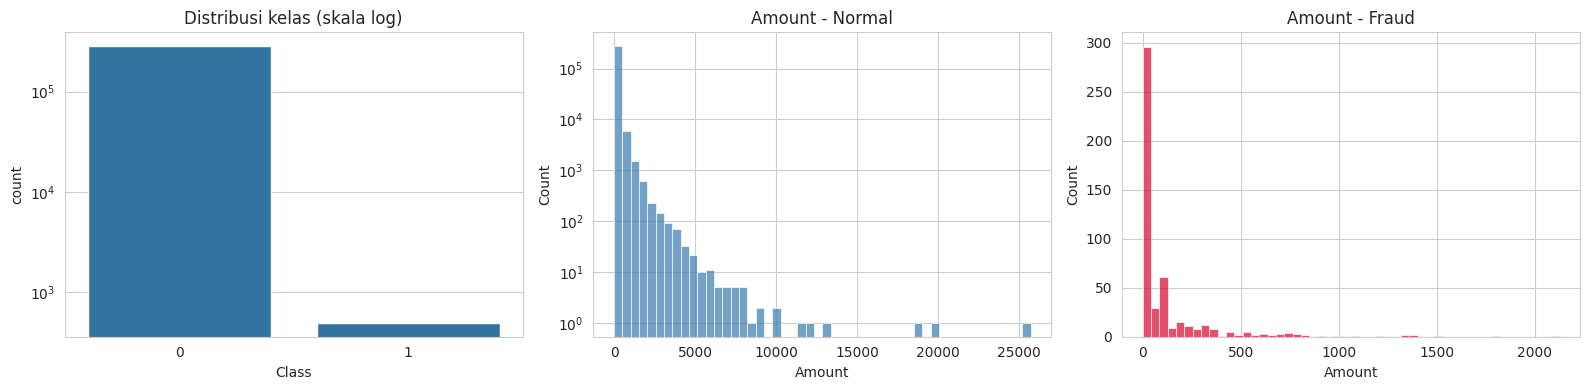

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="Class", data=df, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Distribusi kelas (skala log)")

sns.histplot(df[df.Class == 0]["Amount"], bins=50, ax=axes[1], color="steelblue")
axes[1].set_yscale("log")
axes[1].set_title("Amount - Normal")

sns.histplot(df[df.Class == 1]["Amount"], bins=50, ax=axes[2], color="crimson")
axes[2].set_title("Amount - Fraud")

plt.tight_layout()
plt.show()

#### 💡 Penjelasan: grafik distribusi kelas dan Amount
**Proses:** tiga grafik: jumlah transaksi per kelas (skala log), histogram `Amount` transaksi normal, dan histogram `Amount` transaksi fraud.

**Output:**
- **Kiri (skala log):** bar kelas 1 (fraud) jauh lebih pendek dari kelas 0. Skala log dipakai karena selisihnya terlalu besar untuk digambar dengan skala biasa.
- **Tengah (normal):** hampir semua transaksi bernilai kecil, dengan ekor panjang sampai lebih dari 25.000. Sumbu y memakai skala log supaya ekor itu terlihat.
- **Kanan (fraud):** menumpuk kuat di nominal sangat kecil (bar pertama sekitar 300 kasus dari 492). Nilai maksimum hanya sekitar 2.100.

**Kesimpulan:** fraud tidak identik dengan nominal besar. Justru banyak fraud bernilai kecil.

In [6]:
print("Statistik Amount per kelas:")
df.groupby("Class")["Amount"].describe()

Statistik Amount per kelas:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


#### 💡 Penjelasan: statistik `Amount` per kelas
| | Mean | Median (50%) | Q1 (25%) | Max |
|---|---|---|---|---|
| Normal | 88,29 | 22,00 | 5,65 | 25.691 |
| Fraud | 122,21 | **9,25** | **1,00** | 2.125 |

- **Mean fraud lebih tinggi** (122 vs 88) karena ada beberapa fraud bernilai besar yang menarik rata-rata ke atas.
- **Median fraud lebih rendah** (9,25 vs 22). Setengah fraud bernilai di bawah 9,25, dan **25% fraud bernilai ≤ 1**.
- Pola ini wajar: penipu sering mencoba kartu curian dengan nominal kecil dulu untuk mengecek apakah kartunya masih aktif.
- Karena distribusi kedua kelas tumpang tindih, `Amount` sendirian bukan penanda fraud yang kuat. Ini terkonfirmasi di SHAP (bagian 8), di mana `Amount` hanya ada di peringkat ke-9.

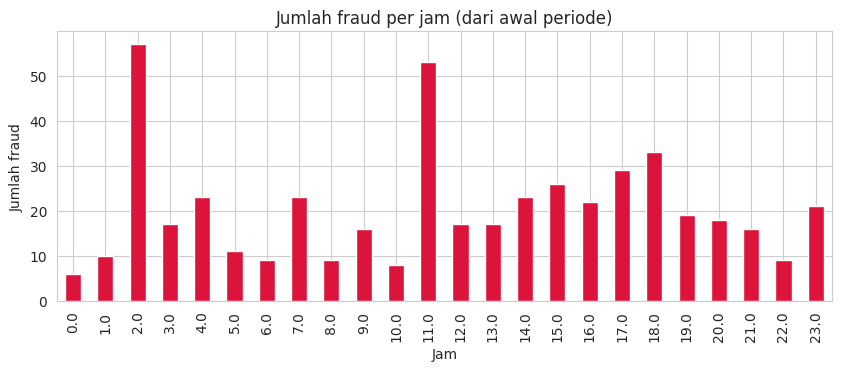

In [7]:
# Fraud sepanjang waktu (Time = detik sejak transaksi pertama)
hour = (df["Time"] // 3600) % 24
fraud_per_hour = hour[df["Class"] == 1].value_counts().sort_index()

plt.figure(figsize=(10, 3.5))
fraud_per_hour.plot(kind="bar", color="crimson")
plt.title("Jumlah fraud per jam (dari awal periode)")
plt.xlabel("Jam")
plt.ylabel("Jumlah fraud")
plt.show()

#### 💡 Penjelasan: fraud per jam
**Proses:** `Time` adalah detik sejak transaksi pertama. Kode mengubahnya menjadi "jam ke-N" dengan `(Time // 3600) % 24`, lalu menghitung fraud per jam.

**Output:** ada dua puncak menonjol di **jam ke-2 (~57 kasus)** dan **jam ke-11 (~53 kasus)**. Jam lain berkisar 6-33 kasus.

**Catatan penting:** ini adalah jam sejak *awal periode data*, **bukan jam dinding** (kita tidak tahu jam berapa transaksi pertama terjadi). Data mencakup 2 hari, jadi tiap batang menggabungkan dua hari. Jangan menulis "fraud sering terjadi jam 2 pagi" di laporan. Cukup katakan fraud tidak tersebar merata sepanjang waktu.

## 3. Kenapa accuracy menyesatkan

Kalau model selalu menebak "bukan fraud", accuracy-nya sudah ~99.8%, tapi model itu tidak berguna sama sekali.

In [8]:
X_all = df.drop(columns=["Class"])
y_all = df["Class"]

dummy = DummyClassifier(strategy="most_frequent").fit(X_all, y_all)
y_dummy = dummy.predict(X_all)

print(f"Accuracy  : {accuracy_score(y_all, y_dummy):.4f}")
print(f"Recall    : {recall_score(y_all, y_dummy):.4f}   <- tidak menangkap satu fraud pun")
print(f"Precision : {precision_score(y_all, y_dummy, zero_division=0):.4f}")

Accuracy  : 0.9983
Recall    : 0.0000   <- tidak menangkap satu fraud pun
Precision : 0.0000


#### 💡 Penjelasan: kenapa accuracy menyesatkan
**Proses:** `DummyClassifier(strategy="most_frequent")` selalu menebak kelas yang paling banyak, yaitu "normal". Ia bukan model sungguhan, hanya alat pembanding.

**Output:**
- **Accuracy 0,9983**: terlihat sangat bagus.
- **Recall 0,0000**: dari 492 fraud, **tidak ada satu pun yang tertangkap**.
- **Precision 0,0000**: tidak pernah menandai fraud, jadi tidak ada tebakan benar.

**Kesimpulan:** accuracy 99,83% didapat tanpa melakukan apa-apa, hanya karena 99,83% transaksi memang normal. Karena itu proyek ini memakai **AUPRC, precision, dan recall**, bukan accuracy.

## 4. Split berdasarkan waktu

Di dunia nyata, model dilatih dengan data lama dan dipakai untuk transaksi baru.
Jadi kita latih di 80% transaksi paling awal dan uji di 20% paling akhir.

Kolom `Time` **tidak dipakai sebagai fitur**, karena nilainya di data uji berada di luar rentang data latih.

In [9]:
df_sorted = df.sort_values("Time").reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:split_idx]
test = df_sorted.iloc[split_idx:]

features = [c for c in df.columns if c not in ["Class", "Time"]]

X_train, y_train = train[features], train["Class"]
X_test, y_test = test[features], test["Class"]

print(f"Train: {X_train.shape[0]:,} baris | fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Test : {X_test.shape[0]:,} baris | fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Train: 227,845 baris | fraud: 417 (0.183%)
Test : 56,962 baris | fraud: 75 (0.132%)


#### 💡 Penjelasan: split berdasarkan waktu
**Proses:**
1. Data diurutkan berdasarkan `Time`.
2. 80% transaksi paling awal jadi **train**, 20% paling akhir jadi **test**. Ini meniru kondisi nyata: model dilatih dengan data lama lalu dipakai untuk transaksi baru. Split acak akan membuat model "mengintip masa depan".
3. `Time` dibuang dari fitur, karena nilainya di data test berada di luar rentang data train dan tidak bisa digeneralisasi.

**Output:**
| | Baris | Fraud | % fraud |
|---|---|---|---|
| Train | 227.845 | 417 | 0,183% |
| Test | 56.962 | **75** | 0,132% |

**Yang harus diperhatikan:** data test hanya punya **75 fraud**. Satu fraud yang tertangkap atau terlewat menggeser recall sekitar 1,3 poin persentase, jadi selisih kecil antar model bisa terjadi hanya karena kebetulan. Cantumkan ini di bagian keterbatasan.

## 5. Model baseline: Logistic Regression

Pakai `class_weight="balanced"` agar model memberi bobot lebih pada kelas fraud yang langka.
Scaling ada di dalam `Pipeline` supaya hanya "belajar" dari data train (tidak ada data leakage).

In [10]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])
baseline.fit(X_train, y_train)

y_proba = baseline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

#### 💡 Penjelasan: melatih baseline
**Proses:**
- `StandardScaler` menyamakan skala fitur (LogReg sensitif terhadap skala).
- `LogisticRegression(class_weight="balanced")` memberi bobot lebih besar pada fraud yang langka, supaya model tidak mengabaikannya.
- `Pipeline` menggabungkan keduanya, sehingga scaler hanya belajar dari data train (tidak ada data leakage dari data test).
- `predict_proba(...)[:, 1]` menghasilkan **probabilitas fraud** tiap transaksi. `y_pred` mengubahnya menjadi keputusan 0/1 dengan **threshold 0,5**.

In [11]:
auprc = average_precision_score(y_test, y_proba)
random_auprc = y_test.mean()  # AUPRC model acak = proporsi fraud

print(f"AUPRC (baseline LogReg) : {auprc:.4f}")
print(f"AUPRC (tebakan acak)    : {random_auprc:.4f}")
print(f"Precision               : {precision_score(y_test, y_pred):.4f}")
print(f"Recall                  : {recall_score(y_test, y_pred):.4f}")
print(f"F1                      : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"], digits=4))

AUPRC (baseline LogReg) : 0.7622
AUPRC (tebakan acak)    : 0.0013
Precision               : 0.0441
Recall                  : 0.9067
F1                      : 0.0842

              precision    recall  f1-score   support

      Normal     0.9999    0.9741    0.9868     56887
       Fraud     0.0441    0.9067    0.0842        75

    accuracy                         0.9740     56962
   macro avg     0.5220    0.9404    0.5355     56962
weighted avg     0.9986    0.9740    0.9856     56962



#### 💡 Penjelasan: metrik baseline
| Metrik | Nilai | Artinya |
|---|---|---|
| **AUPRC** | 0,7622 | Kemampuan model mengurutkan fraud di atas transaksi normal. Tebakan acak hanya 0,0013 (sama dengan proporsi fraud di data test), jadi model ini sangat jauh di atas acak. |
| **Precision** | 0,0441 | Dari semua transaksi yang ditandai fraud, hanya 4,4% yang benar-benar fraud. |
| **Recall** | 0,9067 | Dari 75 fraud, 90,7% tertangkap (68 dari 75). |
| **F1** | 0,0842 | Rata-rata harmonik precision dan recall, jadi sangat rendah karena precision-nya buruk. |

**Kesimpulan:** baseline ini menangkap hampir semua fraud, tapi dengan banyak sekali false alarm. Di `classification_report`, accuracy 0,9740 sebenarnya **lebih rendah** dari model malas (0,9983), padahal model ini jauh lebih berguna. Itu bukti nyata bahwa accuracy menyesatkan.

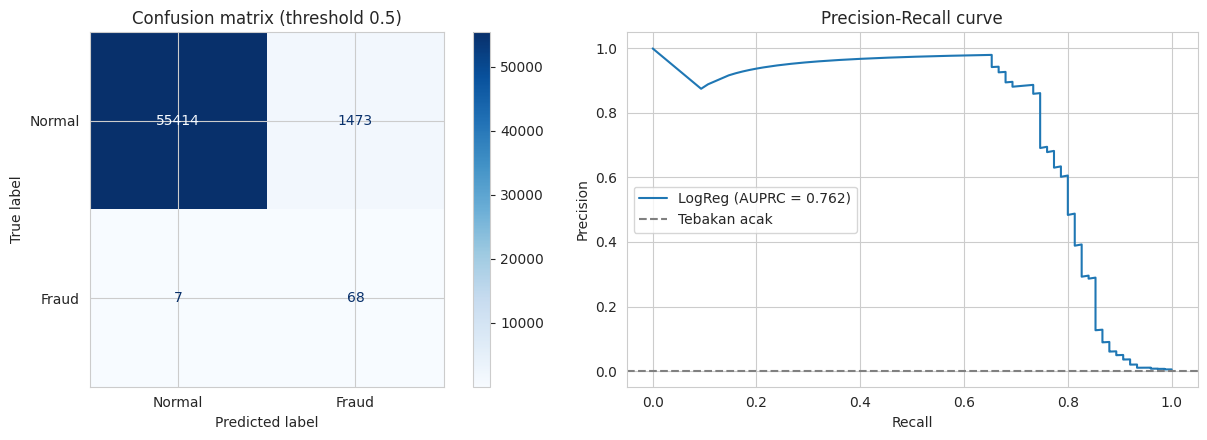

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"]).plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title("Confusion matrix (threshold 0.5)")

prec, rec, thr = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec, prec, label=f"LogReg (AUPRC = {auprc:.3f})")
axes[1].axhline(random_auprc, color="gray", linestyle="--", label="Tebakan acak")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.tight_layout()
plt.show()

#### 💡 Penjelasan: confusion matrix & kurva precision-recall
**Confusion matrix (threshold 0,5):**
| | Diprediksi Normal | Diprediksi Fraud |
|---|---|---|
| **Aktual Normal** | 55.414 (TN, benar) | 1.473 (FP, false alarm) |
| **Aktual Fraud** | 7 (FN, fraud lolos) | 68 (TP, fraud tertangkap) |

- Recall = 68 / (68 + 7) = 90,7%.
- Precision = 68 / (68 + 1.473) = 4,4%.
- Dari 1.541 transaksi yang ditandai, hanya 68 yang fraud, jadi kira-kira **22 false alarm untuk setiap 1 fraud sungguhan**. Di praktik, ini berarti tim review kewalahan dan nasabah sering terganggu.

**Kurva precision-recall:**
- Sumbu x = recall, sumbu y = precision. Makin ke kanan-atas makin baik.
- Precision bertahan sekitar 0,98 sampai recall ~0,65, lalu turun tajam. Model bagus dalam mengurutkan fraud, hanya saja titik operasi harus dipilih dengan baik.
- **Threshold 0,5 jatuh di ujung kanan kurva** (recall tinggi, precision sangat rendah). Jadi kurvanya bagus (AUPRC 0,76) tapi keputusan di threshold 0,5 kurang bagus. AUPRC menilai kualitas *urutan*, threshold menentukan *titik operasi*.
- Garis putus-putus abu-abu = tebakan acak (hampir 0).

> Baseline biasanya punya **recall tinggi tapi precision rendah** (banyak false alarm).
> Ini normal untuk `class_weight="balanced"`. Bagian berikutnya mencoba model yang lebih baik.

## 6. Bandingkan model & strategi imbalance

- **LogReg**: baseline dari bagian 5
- **Random Forest**: `class_weight="balanced_subsample"`
- **XGBoost**: `scale_pos_weight` = rasio normal : fraud
- **XGBoost + SMOTE**: membuat data fraud sintetis. SMOTE **hanya** diterapkan pada data train, tidak pernah pada data test.

Metrik utama: **AUPRC**. Precision, recall, dan F1 dihitung pada threshold 0.5.

In [13]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

def make_xgb(**kwargs):
    return XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="aucpr", tree_method="hist",
        n_jobs=-1, random_state=RANDOM_STATE, **kwargs
    )

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=5,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE
    ),
    "XGBoost": make_xgb(scale_pos_weight=neg / pos),
}

probas = {"LogReg (balanced)": y_proba}   # baseline dari bagian 5
for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_train)
    probas[name] = model.predict_proba(X_test)[:, 1]

Training Random Forest ...
Training XGBoost ...


#### 💡 Penjelasan: melatih Random Forest & XGBoost
**Proses:**
- **Random Forest:** 100 pohon, kedalaman maksimum 12, `class_weight="balanced_subsample"` (bobot kelas dihitung ulang tiap pohon).
- **XGBoost:** 300 pohon boosting, `learning_rate=0.05`, dan **`scale_pos_weight = neg / pos`** (sekitar 545 (dihitung), yaitu rasio normal : fraud di data train). Parameter ini membuat kesalahan pada fraud "dihukum" lebih berat.
- `eval_metric="aucpr"` membuat XGBoost mengukur kualitas dengan area di bawah kurva precision-recall, sesuai metrik utama proyek ini.
- Setiap model dilatih di **data train saja**, lalu menghasilkan probabilitas untuk data test. Probabilitas disimpan di `probas` untuk dibandingkan.

**Output:** hanya dua baris `Training ...`. Nilai metriknya ada di tabel berikutnya.

In [14]:
# XGBoost + SMOTE (resampling hanya pada data train)
smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)  # fraud jadi 10% dari normal
X_res, y_res = smote.fit_resample(X_train, y_train)
print("Setelah SMOTE - fraud:", y_res.sum(), "| normal:", (y_res == 0).sum())

xgb_smote = make_xgb()
xgb_smote.fit(X_res, y_res)
probas["XGBoost + SMOTE"] = xgb_smote.predict_proba(X_test)[:, 1]

Setelah SMOTE - fraud: 22742 | normal: 227428


#### 💡 Penjelasan: SMOTE
**Proses:**
- **SMOTE** membuat contoh fraud *sintetis* dengan menginterpolasi antara fraud yang sudah ada dan tetangga terdekatnya.
- `sampling_strategy=0.1` berarti jumlah fraud dinaikkan sampai 10% dari jumlah normal.
- **SMOTE hanya dijalankan pada data train (`X_train`)**, tidak pernah pada data test. Kalau tidak, data sintetis bisa bocor ke evaluasi dan hasilnya jadi terlalu bagus.

**Output:** `fraud: 22742 | normal: 227428`. Fraud naik dari **417 asli menjadi 22.742**. Artinya ~22.300 di antaranya adalah data sintetis. Jumlah normal tidak berubah. Rasionya kini 10%, sebelumnya hanya 0,18%.

In [15]:
def evaluate(name, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {
        "Model": name,
        "AUPRC": average_precision_score(y_true, proba),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
    }

results = pd.DataFrame([evaluate(n, y_test, p) for n, p in probas.items()])
results = results.sort_values("AUPRC", ascending=False).reset_index(drop=True)
results.round(4)

,Model,AUPRC,Precision,Recall,F1
0,Random Forest,0.8233,0.9333,0.7467,0.8296
1,XGBoost,0.7918,0.7808,0.7600,0.7703
2,XGBoost + SMOTE,0.7899,0.7917,0.7600,0.7755
3,LogReg (balanced),0.7622,0.0441,0.9067,0.0842


#### 💡 Penjelasan: tabel perbandingan model
| Model | AUPRC | Precision | Recall | F1 | TP / FP *(dihitung)* |
|---|---|---|---|---|---|
| Random Forest | **0,8233** | 0,933 | 0,747 | 0,830 | 56 / 4 |
| XGBoost | 0,7918 | 0,781 | 0,760 | 0,770 | 57 / 16 |
| XGBoost + SMOTE | 0,7899 | 0,792 | 0,760 | 0,776 | 57 / 15 |
| LogReg (balanced) | 0,7622 | 0,044 | 0,907 | 0,084 | 68 / 1.473 |

**Temuan:**
1. **Model pohon jauh lebih presisi dari LogReg.** False alarm turun dari 1.473 menjadi 4-16, dengan recall hanya turun dari ~91% ke ~75%. F1 naik dari 0,08 menjadi 0,77-0,83.
2. **Random Forest punya AUPRC tertinggi, tapi selisih dengan XGBoost (0,03) kecil.** Dengan hanya 75 fraud di data test, selisih itu setara satu-dua transaksi dan tidak cukup untuk menyimpulkan RF pasti lebih baik. Aman dikatakan: RF dan XGBoost setara dan sama-sama jauh di atas baseline.
3. **SMOTE tidak membantu.** AUPRC 0,7899 vs 0,7918 tanpa SMOTE. `scale_pos_weight` sudah cukup menangani imbalance. Hasil "tidak membantu" ini valid dan layak ditulis.
4. **Model final yang dipakai di bagian selanjutnya adalah XGBoost**, bukan RF. Alasannya: performa setara, mudah dijelaskan dengan SHAP, dan model file-nya ringan. Nyatakan pilihan ini di README.

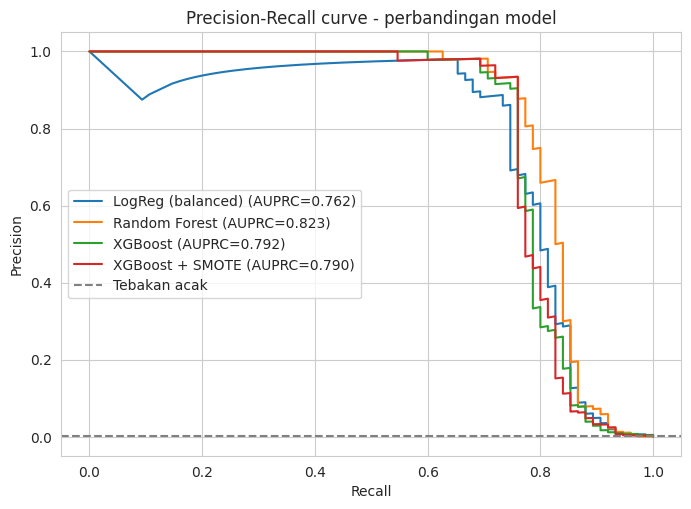

In [16]:
plt.figure(figsize=(8, 5.5))
for name, p in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    plt.plot(rec, prec, label=f"{name} (AUPRC={average_precision_score(y_test, p):.3f})")
plt.axhline(y_test.mean(), color="gray", linestyle="--", label="Tebakan acak")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve - perbandingan model")
plt.legend()
plt.show()

#### 💡 Penjelasan: kurva PR semua model
- Semua model pohon mempertahankan **precision mendekati 1,0 sampai recall ~0,55-0,7**, artinya untuk sebagian besar fraud yang "mudah", tebakan mereka hampir selalu benar.
- Setelah itu semua kurva turun: fraud yang tersisa sulit dibedakan dari transaksi normal.
- Kurva **LogReg (biru)** sedikit lebih rendah di sisi kiri (precision ~0,9-0,98, sementara model pohon hampir 1,0), sedangkan **Random Forest (oranye)** paling tinggi di area recall 0,7-0,85, itulah asal AUPRC tertingginya.
- XGBoost dan XGBoost + SMOTE hampir berimpit, konsisten dengan tabel sebelumnya (SMOTE tidak berpengaruh).
- Semua model jauh di atas garis putus-putus (tebakan acak).

**Cara memilih:** kalau bank ingin menangkap sebanyak mungkin fraud dan siap menerima false alarm, pilih titik di sisi kanan kurva. Kalau ingin false alarm minimal, pilih titik di sisi kiri. Bagian berikutnya memilih titik itu berdasarkan biaya.

## 7. Tuning threshold dengan biaya bisnis

Threshold 0.5 belum tentu optimal. Kita pilih threshold yang meminimalkan **total biaya**:

- **Fraud yang lolos (false negative)**: bank rugi sebesar `Amount` transaksi itu.
- **False alarm (false positive)**: biaya tetap untuk review manual / mengganggu nasabah.

> `FALSE_ALARM_COST` di bawah adalah **asumsi**. Ubah sesuai skenario, dan jelaskan asumsinya di laporan.

Agar adil, threshold dipilih di **data validasi** (bagian akhir data train), lalu diuji sekali di data test.

In [17]:
FALSE_ALARM_COST = 5.0   # asumsi biaya per false alarm (misal: USD 5)

def total_cost(y_true, proba, amount, thr):
    y_true = np.asarray(y_true)
    amount = np.asarray(amount)
    pred = proba >= thr
    missed_fraud = (y_true == 1) & (~pred)
    false_alarm = (y_true == 0) & pred
    return amount[missed_fraud].sum() + FALSE_ALARM_COST * false_alarm.sum()

# Train dibagi lagi berdasarkan waktu: 80% train_sub, 20% validasi
val_idx = int(len(train) * 0.8)
train_sub, val = train.iloc[:val_idx], train.iloc[val_idx:]

xgb_val = make_xgb(scale_pos_weight=(train_sub["Class"] == 0).sum() / (train_sub["Class"] == 1).sum())
xgb_val.fit(train_sub[features], train_sub["Class"])
val_proba = xgb_val.predict_proba(val[features])[:, 1]

thresholds = np.linspace(0.01, 0.99, 99)
val_costs = [total_cost(val["Class"], val_proba, val["Amount"], t) for t in thresholds]
best_thr = thresholds[int(np.argmin(val_costs))]
print(f"Threshold terbaik (dari validasi): {best_thr:.2f}")

Threshold terbaik (dari validasi): 0.83


#### 💡 Penjelasan: memilih threshold dengan biaya bisnis
**Proses:**
1. **Fungsi biaya `total_cost`:** fraud yang lolos dihitung rugi sebesar `Amount` transaksinya, dan setiap false alarm dihitung `FALSE_ALARM_COST` = **USD 5** (ini *asumsi*, bebas diubah).
2. **Data train dibagi lagi berdasarkan waktu:** 80% `train_sub` dan 20% `val` (validasi).
3. Model XGBoost dilatih di `train_sub`, lalu untuk 99 threshold (0,01-0,99) dihitung total biaya di `val`.
4. **Threshold dengan biaya terendah di validasi dipilih.** Pemilihan di data validasi (bukan test) penting supaya evaluasi test tetap jujur (tidak "mengintip").

**Output:** `Threshold terbaik (dari validasi): 0.83`.

In [18]:
xgb_final = models["XGBoost"]          # model yang dilatih di seluruh data train
test_proba = probas["XGBoost"]
amount_test = test["Amount"].values

cost_default = total_cost(y_test, test_proba, amount_test, 0.5)
cost_tuned = total_cost(y_test, test_proba, amount_test, best_thr)
cost_no_model = amount_test[y_test.values == 1].sum()   # semua fraud lolos

print(f"Tanpa model (semua fraud lolos)      : ${cost_no_model:,.0f}")
print(f"Model, threshold 0.50                : ${cost_default:,.0f}")
print(f"Model, threshold {best_thr:.2f} (tuned)      : ${cost_tuned:,.0f}")
print(f"Penghematan vs tanpa model           : {(1 - cost_tuned / cost_no_model) * 100:.1f}%")

pred_tuned = (test_proba >= best_thr).astype(int)
print(f"\nPada threshold {best_thr:.2f}: precision={precision_score(y_test, pred_tuned, zero_division=0):.3f}, "
      f"recall={recall_score(y_test, pred_tuned):.3f}")

Tanpa model (semua fraud lolos)      : $7,729
Model, threshold 0.50                : $2,718
Model, threshold 0.83 (tuned)      : $2,678
Penghematan vs tanpa model           : 65.3%

Pada threshold 0.83: precision=0.877, recall=0.760


#### 💡 Penjelasan: hasil biaya di data test
**Proses:** model final XGBoost (dilatih di seluruh data train) dievaluasi di data test dengan tiga skenario.

| Skenario | Biaya |
|---|---|
| Tanpa model (semua fraud lolos) | USD 7.729 |
| Model, threshold 0,50 | USD 2.718 |
| Model, threshold 0,83 (dari validasi) | **USD 2.678** |

- **Penghematan 65,3%** dibanding tanpa model.
- Pada threshold 0,83: precision 0,877 dan recall 0,760, jadi sekitar 57 fraud tertangkap, 18 lolos, dan sekitar 8 false alarm *(dihitung)*. Sebagian besar biayanya berasal dari 18 fraud yang lolos, bukan dari false alarm (8 × USD 5 = USD 40).
- **Perbandingan yang jujur:** threshold yang di-tuning hanya menghemat sekitar **USD 40** dibanding threshold 0,5. Lompatan penghematan terbesar datang dari memakai model, bukan dari tuning threshold.
- Nilai dolar terlihat kecil karena `Amount` dataset ini kecil dan biaya false alarm adalah asumsi. Sajikan ini sebagai **simulasi**, bukan klaim penghematan nyata.

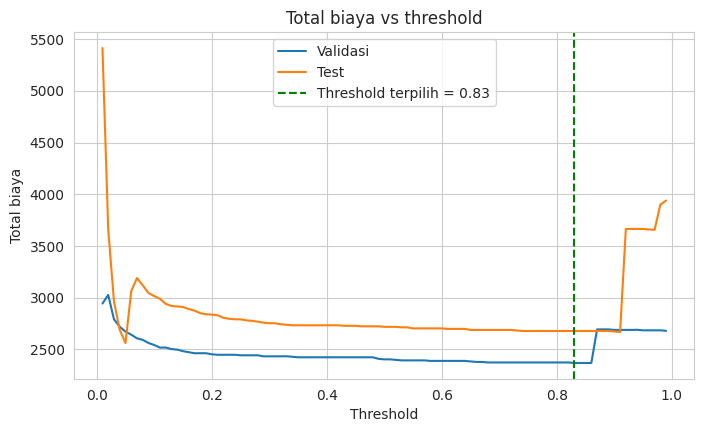

In [19]:
test_costs = [total_cost(y_test, test_proba, amount_test, t) for t in thresholds]

plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, val_costs, label="Validasi")
plt.plot(thresholds, test_costs, label="Test")
plt.axvline(best_thr, color="green", linestyle="--", label=f"Threshold terpilih = {best_thr:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Total biaya")
plt.title("Total biaya vs threshold")
plt.legend()
plt.show()

#### 💡 Penjelasan: kurva biaya vs threshold
- **Sumbu x:** threshold. **Sumbu y:** total biaya (makin rendah makin baik). Garis biru = validasi, oranye = test, garis putus hijau = threshold terpilih (0,83).
- **Area datar:** biaya hampir konstan dari threshold ~0,1 sampai ~0,9. Artinya pilihan threshold tidak terlalu sensitif di rentang itu, dan tidak ada satu "angka ajaib".
- **Threshold terlalu rendah (< 0,05)**: biaya melonjak (test sampai ~USD 5.400) karena banyak transaksi normal dianggap fraud, jadi biaya false alarm menumpuk.
- **Ada "tebing" di sisi kanan:** di validasi biaya naik tiba-tiba sekitar 0,86, dan di test sekitar 0,92. Ini terjadi karena beberapa fraud bernilai besar punya probabilitas tepat di area itu. Threshold 0,83 berada dekat tebing tersebut, jadi memilih titik di tengah area datar (misalnya 0,5-0,7) sebenarnya lebih aman. Ini pertimbangan yang bagus untuk disebut di README.
- Biaya test terendah (sekitar USD 2.560) ada di threshold ~0,05, tapi itu hanya bisa diketahui dengan melihat data test. Memakai threshold validasi adalah cara yang benar.
- Level kurva validasi (~USD 2.400) dan test (~USD 2.700) berbeda karena isi fraud-nya berbeda. Yang penting adalah bentuk kurvanya mirip.

## 8. Penjelasan model dengan SHAP

SHAP menunjukkan fitur mana yang paling memengaruhi prediksi. Karena V1-V28 sudah di-anonimkan,
kita hanya bisa bilang "V14 penting", bukan "kenapa" secara bisnis. Itu adalah keterbatasan dataset ini.

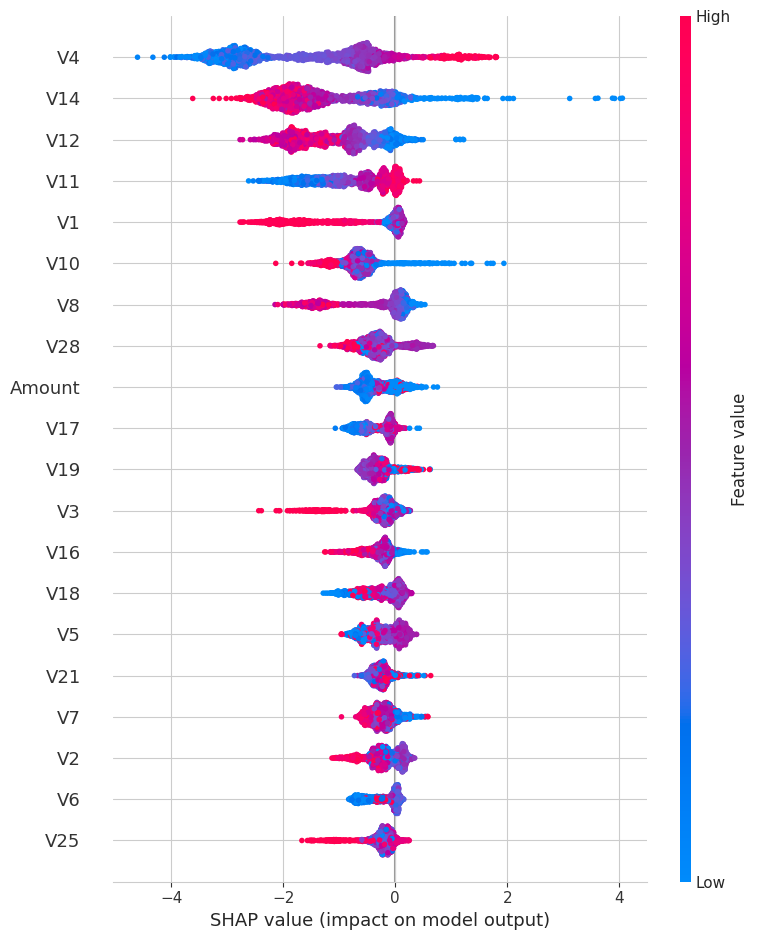

In [20]:
import shap

sample = X_test.sample(2000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, show=True)

#### 💡 Penjelasan: SHAP summary plot
**Proses:**
- `TreeExplainer` menghitung nilai SHAP untuk model XGBoost. Nilai SHAP menunjukkan seberapa besar sebuah fitur mendorong prediksi ke arah fraud atau normal untuk **satu transaksi tertentu**.
- Dihitung pada 2.000 transaksi acak dari data test (bukan semua, supaya cepat).

**Cara membaca grafik:**
- Tiap **titik** = satu transaksi. Tiap **baris** = satu fitur, diurutkan dari yang paling berpengaruh (atas).
- **Sumbu x:** pengaruh terhadap output model (dalam log-odds). **Kanan (positif) = mendorong ke fraud**, kiri (negatif) = mendorong ke normal.
- **Warna:** nilai fitur. Merah = tinggi, biru = rendah.

**Yang terlihat:**
- **V4:** nilai tinggi (merah) ada di kanan, jadi V4 tinggi mendorong ke fraud.
- **V14 dan V12:** nilai **rendah** (biru) ada di kanan, jadi nilai rendah mendorong ke fraud.
- **V11:** nilai tinggi cenderung mendorong ke fraud.
- Titik-titik di dekat 0 berarti fitur itu tidak banyak mengubah prediksi transaksi tersebut.

**Batasan:** V1-V28 adalah hasil PCA yang dianonimkan, jadi kita hanya bisa mengatakan "V14 yang rendah menaikkan risiko", bukan *mengapa* secara bisnis. SHAP juga menjelaskan perilaku model, **bukan** hubungan sebab-akibat di dunia nyata.

In [21]:
# Ranking fitur berdasarkan rata-rata |SHAP|
importance = pd.Series(np.abs(shap_values).mean(axis=0), index=sample.columns).sort_values(ascending=False)
importance.head(10).round(4)

,0
V4,1.6418
V14,1.3803
V12,1.0563
V11,0.7765
V1,0.7555
V10,0.7073
V8,0.4987
V28,0.3897
Amount,0.3628
V17,0.3546


#### 💡 Penjelasan: peringkat fitur
Angka = rata-rata nilai absolut SHAP (makin besar, makin berpengaruh secara keseluruhan).

| Peringkat | Fitur | Mean abs SHAP |
|---|---|---|
| 1 | V4 | 1,64 |
| 2 | V14 | 1,38 |
| 3 | V12 | 1,06 |
| 4 | V11 | 0,78 |
| 5 | V1 | 0,76 |
| 6 | V10 | 0,71 |
| 9 | Amount | 0,36 |

- Empat fitur teratas (V4, V14, V12, V11) mendominasi keputusan model.
- **`Amount` hanya di peringkat ke-9.** Ini konsisten dengan temuan EDA: nominal transaksi bukan penanda fraud yang kuat.
- Fitur di luar 10 besar punya pengaruh jauh lebih kecil.

## 9. Demo: prediksi satu transaksi + simpan model

Fungsi di bawah menerima **satu transaksi** dan mengeluarkan probabilitas fraud serta keputusan model.
Nanti fungsi ini bisa dipakai di aplikasi web (Streamlit).

In [22]:
def predict_transaction(row: pd.DataFrame, model=xgb_final, threshold=best_thr):
    proba = model.predict_proba(row[features])[0, 1]
    label = "FRAUD" if proba >= threshold else "NORMAL"
    return proba, label

# Contoh 1: transaksi acak dari data test
row = X_test.sample(1, random_state=None)
actual = y_test.loc[row.index[0]]
proba, label = predict_transaction(row)
print(f"[Acak]  Amount: {row['Amount'].iloc[0]:.2f} | P(fraud) = {proba:.3f} | Prediksi: {label} | Aktual: {'FRAUD' if actual else 'NORMAL'}")

# Contoh 2: transaksi yang sebenarnya fraud
row = X_test[y_test == 1].sample(1, random_state=None)
proba, label = predict_transaction(row)
print(f"[Fraud] Amount: {row['Amount'].iloc[0]:.2f} | P(fraud) = {proba:.3f} | Prediksi: {label} | Aktual: FRAUD")

[Acak]  Amount: 0.99 | P(fraud) = 0.000 | Prediksi: NORMAL | Aktual: NORMAL
[Fraud] Amount: 0.00 | P(fraud) = 1.000 | Prediksi: FRAUD | Aktual: FRAUD


#### 💡 Penjelasan: demo prediksi satu transaksi
**Proses:** `predict_transaction` menerima satu baris transaksi, menghitung `P(fraud)` dengan model XGBoost, lalu membandingkannya dengan threshold 0,83 untuk memutuskan FRAUD atau NORMAL. Dicoba pada dua transaksi dari data test.

**Output:**
- **Transaksi acak:** P(fraud) = 0,000, prediksi NORMAL, aktual NORMAL. **Benar.**
- **Transaksi fraud:** Amount 187,11, P(fraud) = 0,001, prediksi NORMAL, aktual FRAUD. **Fraud lolos (false negative).**

**Kenapa fraud itu lolos?** Model menangkap sekitar 76% fraud, jadi sekitar 1 dari 4 fraud memang terlewat. Transaksi ini kelihatan seperti transaksi normal bagi model (probabilitasnya hanya 0,1%), sehingga jauh dari threshold. Ini normal, dan bagus untuk ditunjukkan di demo: **model tidak sempurna**, dan mengetahui batas kemampuannya adalah bagian dari proyek yang baik.

Karena `random_state=None`, hasilnya berbeda setiap kali sel dijalankan. Coba beberapa kali untuk melihat contoh fraud yang tertangkap.

In [23]:
# Simpan model + threshold + daftar fitur untuk dipakai di aplikasi nanti
joblib.dump(
    {"model": xgb_final, "threshold": float(best_thr), "features": features},
    "fraud_model.joblib",
)
print("Model tersimpan: fraud_model.joblib")

# Kalau ingin mengunduh dari Colab:
# from google.colab import files
# files.download("fraud_model.joblib")

Model tersimpan: fraud_model.joblib


In [24]:
import xgboost, sklearn
sample = pd.concat([
    test[test["Class"] == 0].sample(2000, random_state=42),
    test[test["Class"] == 1],
]).sample(frac=1, random_state=42)
sample[features + ["Class"]].to_csv("sample_transactions.csv", index=False)

print("xgboost   ==", xgboost.__version__)
print("scikit-learn ==", sklearn.__version__)

from google.colab import files
files.download("fraud_model.joblib")
files.download("sample_transactions.csv")

xgboost   == 3.4.1
scikit-learn == 1.6.1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### 💡 Penjelasan: menyimpan model & mengekspor data untuk aplikasi
**Proses:**
- `joblib.dump` menyimpan tiga hal dalam satu file `fraud_model.joblib`: model XGBoost, threshold terpilih (0,83), dan daftar nama fitur, supaya aplikasi Streamlit tahu urutan kolom.
- `sample_transactions.csv` berisi 2.000 transaksi normal acak + **semua fraud di data test** (75), diacak urutannya. File ini dipakai tombol "Transaksi acak/fraud/normal" di aplikasi.
- Versi library dicetak: **xgboost 3.4.1** dan **scikit-learn 1.6.1**. Di `requirements.txt` aplikasi, pakai versi persis ini (`xgboost==3.4.1`, `scikit-learn==1.6.1`) supaya model bisa dimuat tanpa error.
- `files.download(...)` memicu unduhan ke komputer (cell display `Javascript object` di output adalah bagian dari itu, bukan error).

---
## 📌 Ringkasan temuan

**Masalah:** mendeteksi transaksi kartu kredit fraud pada data yang sangat tidak seimbang (492 fraud dari 284.807 transaksi, 0,17%).

**Metodologi**
- Metrik utama **AUPRC** (bukan accuracy). Model yang selalu menjawab "normal" punya accuracy 99,83% tapi recall 0%.
- **Split berdasarkan waktu** (80% awal train, 20% akhir test), `Time` tidak dipakai sebagai fitur, dan SMOTE hanya diterapkan pada data train.
- Threshold dipilih di **data validasi** berdasarkan biaya bisnis, lalu diuji sekali di data test.

**Hasil (data test, 75 fraud)**
| Model | AUPRC | Precision | Recall |
|---|---|---|---|
| LogReg (baseline) | 0,762 | 0,044 | 0,907 |
| XGBoost | 0,792 | 0,781 | 0,760 |
| Random Forest | 0,823 | 0,933 | 0,747 |

**Insight**
1. Model pohon memangkas false alarm dari 1.473 menjadi 4-16 dengan recall ~75%.
2. SMOTE tidak menambah performa dibanding `scale_pos_weight`.
3. Dalam simulasi biaya (asumsi USD 5 per false alarm), model menurunkan biaya sekitar **65%** dibanding tanpa model.
4. Fitur paling berpengaruh: V4, V14, V12, V11. `Amount` hanya peringkat 9.

**Keterbatasan**
- Data uji hanya 75 fraud, jadi selisih kecil antar model tidak bisa dianggap signifikan.
- Fitur V1-V28 dianonimkan (PCA), jadi tidak bisa dijelaskan secara bisnis.
- Data hanya mencakup 2 hari, sehingga tidak menangkap perubahan pola fraud dari waktu ke waktu.
- 1.081 baris duplikat tidak dibuang.
- Biaya false alarm (USD 5) adalah asumsi, dan threshold 0,83 dekat dengan "tebing" biaya, jadi sebaiknya diuji kestabilannya.